In [2]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://gitee.com/hongwenzhang/pytorch3d.git to /tmp/pip-req-build-5vihvg_y
  Running command git clone --filter=blob:none --quiet https://gitee.com/hongwenzhang/pytorch3d.git /tmp/pip-req-build-5vihvg_y
  Resolved https://gitee.com/hongwenzhang/pytorch3d.git to commit b6a77ad7aaf41ed90fca80ce6a2bac3c462a7881
  Preparing metadata (pyproject.toml) ... done


Epoch 299/300
  Total Loss: 0.0767
  Silhouette: 0.0755
  Laplacian:  0.0032
  Edge:       0.0030
  Normal:     0.0146
  LR:         0.125000


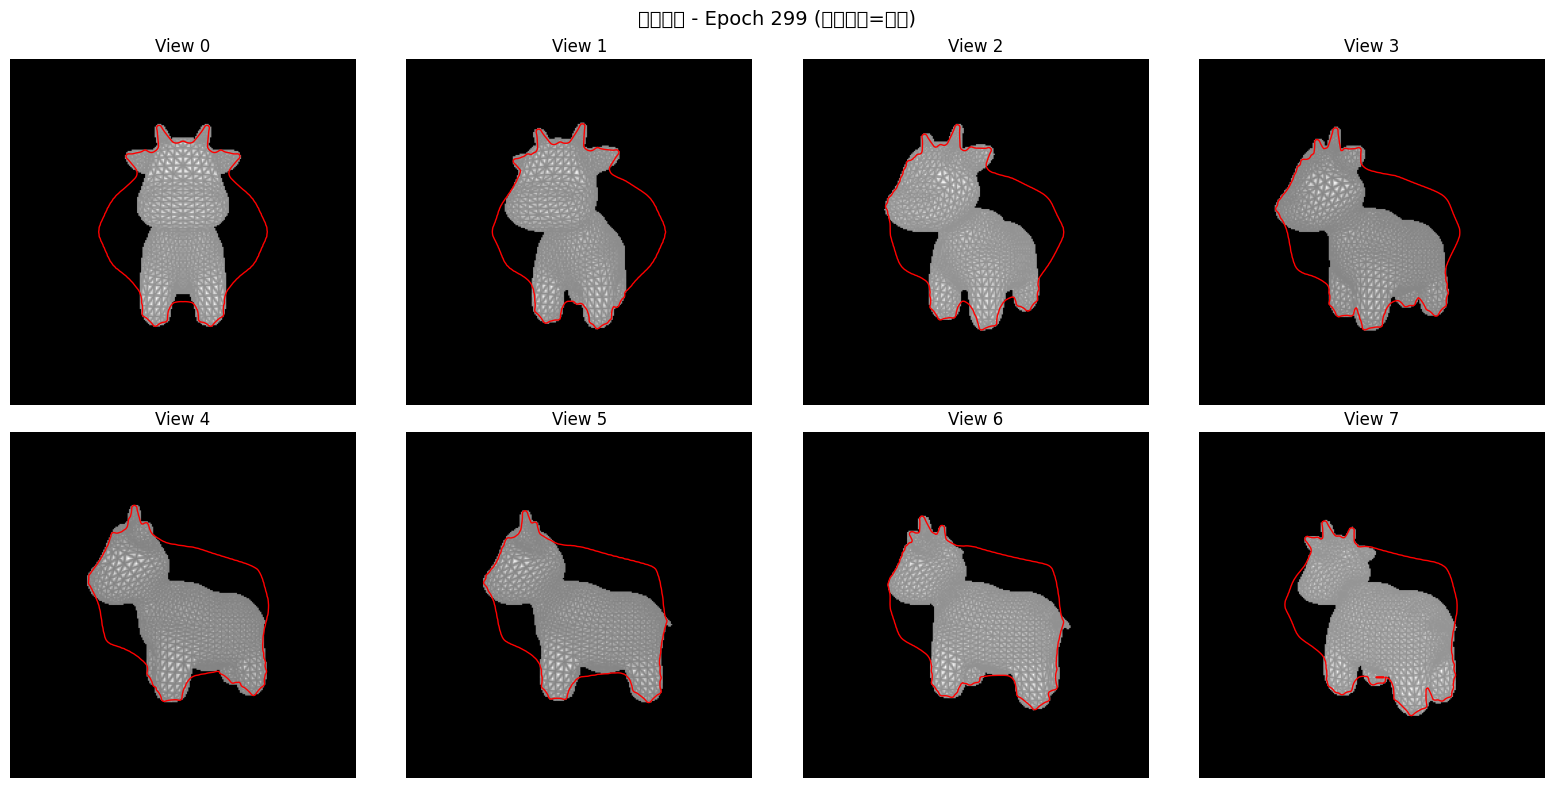


基础实验完成！
输出文件: cow_shape_only.obj
最终顶点数: 2562
最终面数: 5120

渲染最终结果...


/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7808/724674049.py:246: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}

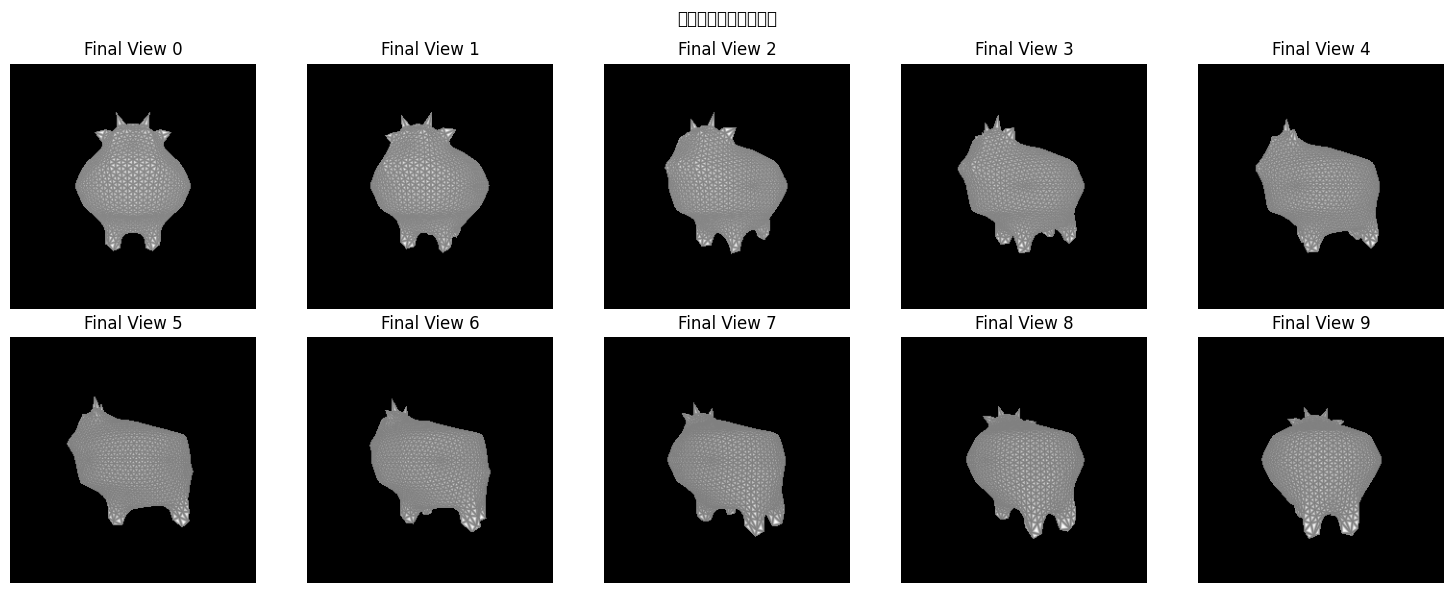

In [13]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)
from pytorch3d.loss import (
    mesh_laplacian_smoothing, mesh_edge_loss, mesh_normal_consistency
)

# 设置设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ============================================
# 基础实验：只优化形状（剪影监督）
# ============================================

class ShapeOnlyOptimizer:
    def __init__(self, target_mesh, target_silhouettes, cameras):
        """
        只优化形状，不优化颜色/纹理
        target_silhouettes: 多视角剪影图 [num_views, H, W] 二值图
        """
        self.target_mesh = target_mesh
        self.target_silhouettes = target_silhouettes
        self.cameras = cameras
        self.num_views = target_silhouettes.shape[0]
        
        # 初始化源网格（细分球体）
        self.src_mesh = ico_sphere(4, device)
        print(f"源网格: {self.src_mesh.verts_packed().shape[0]} 个顶点, "
              f"{self.src_mesh.faces_packed().shape[0]} 个面")
        
        # 可优化的顶点偏移量
        self.deform_verts = torch.zeros_like(self.src_mesh.verts_packed(), 
                                             requires_grad=True)
        
        # 设置软光栅化渲染器
        self.rasterizer = MeshRasterizer(
            cameras=self.cameras,
            raster_settings=RasterizationSettings(
                image_size=256,
                blur_radius=np.log(1.0 / 1e-4 - 1.0) * 1e-4,
                faces_per_pixel=50
            )
        )
        self.shader = SoftSilhouetteShader(
            blend_params=BlendParams(sigma=1e-4, gamma=1e-4)
        )
    
    def compute_loss(self, pred_silhouettes, mesh, epoch):
        """计算损失：剪影误差 + 正则化"""
        # 1. 剪影损失（主要监督信号）
        loss_silhouette = ((pred_silhouettes - self.target_silhouettes) ** 2).mean()
        
        # 2. 正则化损失（防止网格崩溃）
        loss_laplacian = mesh_laplacian_smoothing(mesh)
        loss_edge = mesh_edge_loss(mesh)
        loss_normal = mesh_normal_consistency(mesh)
        
        # 动态调整正则化权重
        if epoch < 100:
            w_lap, w_edge, w_normal = 1.0, 0.1, 0.01
        elif epoch < 200:
            w_lap, w_edge, w_normal = 0.5, 0.05, 0.005
        else:
            w_lap, w_edge, w_normal = 0.3, 0.03, 0.003
        
        total_loss = (loss_silhouette + 
                     w_lap * loss_laplacian + 
                     w_edge * loss_edge + 
                     w_normal * loss_normal)
        
        losses = {
            'silhouette': loss_silhouette.item(),
            'laplacian': loss_laplacian.item(),
            'edge': loss_edge.item(),
            'normal': loss_normal.item(),
            'total': total_loss.item()
        }
        
        return total_loss, losses
    
    def optimize(self, epochs=300, lr=1.0):
        """执行优化循环，返回变形后的网格"""
        optimizer = torch.optim.SGD([self.deform_verts], lr=lr, momentum=0.9)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
        
        print(f"\n开始优化形状，共 {epochs} 轮...")
        print("-" * 60)
        
        for epoch in range(epochs):
            optimizer.zero_grad()
            
            # 变形网格
            deformed_mesh = self.src_mesh.offset_verts(self.deform_verts)
            
            # 渲染剪影（多视角）
            fragments = self.rasterizer(deformed_mesh.extend(self.num_views))
            pred_silhouettes = self.shader(fragments, deformed_mesh.extend(self.num_views))[..., 3]
            
            # 计算损失
            loss, losses = self.compute_loss(pred_silhouettes, deformed_mesh, epoch)
            
            # 反向传播和优化
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            # 可视化
            if epoch % 20 == 0 or epoch == epochs - 1:
                clear_output(wait=True)
                print(f"Epoch {epoch:3d}/{epochs}")
                print(f"  Total Loss: {losses['total']:.4f}")
                print(f"  Silhouette: {losses['silhouette']:.4f}")
                print(f"  Laplacian:  {losses['laplacian']:.4f}")
                print(f"  Edge:       {losses['edge']:.4f}")
                print(f"  Normal:     {losses['normal']:.4f}")
                print(f"  LR:         {scheduler.get_last_lr()[0]:.6f}")
                
                self.visualize(pred_silhouettes, epoch)
        
        # 返回变形后的最终网格
        return self.src_mesh.offset_verts(self.deform_verts)
    
    def visualize(self, pred_silhouettes, epoch):
        """可视化优化过程"""
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        
        for i in range(min(8, self.num_views)):
            row, col = i // 4, i % 4
            axes[row, col].imshow(self.target_silhouettes[i].cpu().numpy(), cmap='gray')
            pred = pred_silhouettes[i].cpu().detach().numpy()
            axes[row, col].contour(pred, levels=[0.5], colors='r', linewidths=1)
            axes[row, col].set_title(f"View {i}")
            axes[row, col].axis('off')
        
        plt.suptitle(f"形状优化 - Epoch {epoch} (红色轮廓=预测)", fontsize=14)
        plt.tight_layout()
        plt.show()


# ============================================
# 准备目标数据（剪影）
# ============================================

def prepare_target_silhouettes(obj_path, num_views=20):
    """从目标模型生成多视角剪影图"""
    verts, faces, _ = load_obj(obj_path)
    faces_idx = faces.verts_idx.to(device)
    verts = verts.to(device)
    verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
    target_mesh = Meshes(verts=[verts], faces=[faces_idx])
    
    cameras = FoVPerspectiveCameras(
        device=device,
        R=look_at_view_transform(2.7, torch.zeros(num_views), 
                                 torch.linspace(-180, 180, num_views))[0],
        T=look_at_view_transform(2.7, torch.zeros(num_views), 
                                 torch.linspace(-180, 180, num_views))[1]
    )
    
    rasterizer = MeshRasterizer(
        cameras=cameras,
        raster_settings=RasterizationSettings(image_size=256, blur_radius=0.0, faces_per_pixel=1)
    )
    shader = SoftSilhouetteShader()
    
    with torch.no_grad():
        fragments = rasterizer(target_mesh.extend(num_views))
        silhouettes = shader(fragments, target_mesh.extend(num_views))[..., 3]
    
    return target_mesh, silhouettes, cameras


# ============================================
# 运行基础实验
# ============================================

if __name__ == "__main__":
    print("=" * 60)
    print("基础实验：从球体优化为奶牛形状（只使用剪影监督）")
    print("=" * 60)
    
    obj_path = "cow.obj"
    if not os.path.exists(obj_path):
        raise FileNotFoundError(f"找不到 {obj_path}，请确保文件存在")
    
    print(f"\n加载目标模型: {obj_path}")
    target_mesh, target_silhouettes, cameras = prepare_target_silhouettes(obj_path, num_views=20)
    print(f"生成了 {target_silhouettes.shape[0]} 个视角的剪影图")
    
    # 显示目标剪影示例
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(10):
        row, col = i // 5, i % 5
        axes[row, col].imshow(target_silhouettes[i].cpu().numpy(), cmap='gray')
        axes[row, col].set_title(f"View {i}")
        axes[row, col].axis('off')
    plt.suptitle("目标多视角剪影图")
    plt.tight_layout()
    plt.show()
    
    # 创建优化器并运行
    optimizer = ShapeOnlyOptimizer(target_mesh, target_silhouettes, cameras)
    final_mesh = optimizer.optimize(epochs=300, lr=1.0)  # 直接返回最终的网格
    
    # 保存结果
    save_obj("cow_shape_only.obj", 
             final_mesh.verts_list()[0].cpu(), 
             final_mesh.faces_list()[0].cpu())
    
    print("\n" + "=" * 60)
    print("基础实验完成！")
    print("输出文件: cow_shape_only.obj")
    print(f"最终顶点数: {len(final_mesh.verts_list()[0])}")
    print(f"最终面数: {len(final_mesh.faces_list()[0])}")
    print("=" * 60)
    
    # 显示最终结果
    print("\n渲染最终结果...")
    rasterizer_final = MeshRasterizer(
        cameras=cameras,
        raster_settings=RasterizationSettings(image_size=256, blur_radius=0.0, faces_per_pixel=1)
    )
    shader_final = SoftSilhouetteShader()
    
    with torch.no_grad():
        fragments = rasterizer_final(final_mesh.extend(20))
        final_silhouettes = shader_final(fragments, final_mesh.extend(20))[..., 3]
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(10):
        row, col = i // 5, i % 5
        axes[row, col].imshow(final_silhouettes[i].cpu().numpy(), cmap='gray')
        axes[row, col].set_title(f"Final View {i}")
        axes[row, col].axis('off')
    plt.suptitle("优化后的多视角剪影图")
    plt.tight_layout()
    plt.show()